<div style="background:linear-gradient(135deg,#0D2B55 0%,#1F497D 60%,#2E86C1 100%);padding:28px 32px;border-radius:10px;margin-bottom:18px"><h1 style="color:white;margin:0 0 6px 0;font-size:1.9em">Financial Risk Management and Engineering — Session 4: Expected Shortfall &amp; Backtesting</h1><p style="color:#BDC3C7;margin:0;font-size:1.0em">Sprott School of Business · Carleton University · Summer 2026</p><p style="color:#85C1E9;margin:8px 0 0 0;font-size:0.9em">ES Parametric &amp; Historical &amp; Monte Carlo · Coherence · GARCH Dynamic Risk · Kupiec · Christoffersen · Basel Traffic-Light · Acerbi-Szekely</p></div>

**Session 4** extends the VaR toolkit (Session 3) to **Expected Shortfall** (ES) — the coherent risk measure that Basel III/IV mandates. We then build a rigorous **backtesting pipeline** that quantifies model accuracy with formal statistical tests.

$$\text{ES}_{\alpha} = -\mathbb{E}[R \mid R \leq \text{VaR}_{\alpha}] = \frac{1}{1-\alpha}\int_0^{1-\alpha} \text{VaR}_{u}\,du$$

**Learning objectives**
1. Compute ES three ways: parametric (normal & Student-t), historical simulation, Monte Carlo
2. Demonstrate ES coherence — a concrete case where VaR violates sub-additivity but ES does not
3. Compare ES/VaR ratios under normal vs heavy-tailed distributions
4. Fit a GARCH(1,1) model for dynamic (time-varying) VaR and ES
5. Run rolling 1-day 99% VaR backtests: Kupiec POF, Christoffersen independence, Basel zones
6. Apply an Acerbi-Szekely ES backtest

**Readings** (session 4 syllabus): Roncalli (2020) *Risk Management*, Ch. 4–5; Financial Risk Manager Handbook, Ch. 3 (backtesting); McNeil, Frey & Embrechts (2015), Ch. 2.2–2.3.

*Reference: Hull (2023) Ch. 11 (&sect;&sect;11.4&ndash;11.10, Expected Shortfall); Jorion (2010) Financial Risk Manager Handbook, Ch. 15 (Advanced Risk Models: Univariate).*

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Setup &mdash; Required Packages &amp; Environment Check</span><br><span style="color:#BDC3C7;font-size:0.93em">Run this first &middot; works on any recent Python 3.9+</span></div>

This notebook uses the standard scientific-Python stack. If you installed **[Anaconda](https://www.anaconda.com/download)** most of these are already present; otherwise install everything in one line (from a terminal, or prefix with `!` in a cell):

```
pip install yfinance pandas numpy matplotlib seaborn scipy arch
```

No installs allowed on your machine? **[Google Colab](https://colab.research.google.com)** runs this notebook free in the browser &mdash; just upload the `.ipynb` and add a first cell with `!pip install yfinance pandas numpy matplotlib seaborn scipy arch`.

<div style="background:#0A2A1A;border-left:5px solid #1E8449;padding:12px 18px;border-radius:0 8px 8px 0;margin:10px 0"><span style="color:#52C97A;font-weight:bold">&#10003; Environment check &nbsp;</span><span style="color:#90D4A8;line-height:1.7">Run the cell below. Every line should print a version number. Anything marked <code>NOT INSTALLED</code> tells you exactly what to <code>pip install</code>, then <b>Kernel &rarr; Restart &amp; Run All</b>.</span></div>

In [1]:
import importlib, sys
print('Python', sys.version.split()[0], '\n')
for pkg in ['numpy', 'pandas', 'matplotlib', 'scipy', 'yfinance', 'arch', 'seaborn']:
    try:
        m = importlib.import_module(pkg)
        print(f'  {pkg:13s} {getattr(m, "__version__", "ok")}')
    except Exception:
        print(f'  {pkg:13s} NOT INSTALLED  ->  pip install {pkg}')

Python 3.13.3 

  numpy         2.1.3
  pandas        2.2.3
  matplotlib    3.10.0
  scipy         1.17.1
  yfinance      0.2.55
  arch          8.0.0
  seaborn       0.13.2


<div style="border-left:5px solid #D4A017;background:#1C1400;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#F0B429">&#128172;</b> <b>When things break.</b> <b>Run cells top to bottom</b> &mdash; order matters. If results look wrong, <b>Kernel &rarr; Restart &amp; Run All</b>. Common errors: <code>ModuleNotFoundError</code> &rarr; <code>pip install &lt;name&gt;</code> then restart; <code>NameError</code> &rarr; you skipped the cell that defines it; <code>YFRateLimitError</code> &rarr; Yahoo throttled you, wait a minute &mdash; this notebook caches data in <code>notebook_data/</code> so a re-run works offline. Read the <b>last</b> line of a traceback first.</div>

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 0 — Setup: Imports, Parameters &amp; Data</span><br><span style="color:#BDC3C7;font-size:0.93em">Slide 1 · Environment · SPY + portfolio · 2021-07-01 to 2026-07-01</span></div>

In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yfinance as yf
from scipy import stats
from scipy.stats import norm, t as t_dist, chi2
from arch import arch_model
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (13, 5), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 12,
    'figure.dpi': 120
})

# ── Global parameters ────────────────────────────────────────────────────────
START     = '2021-07-01'
END       = '2026-07-01'
RF_ANNUAL = 0.04        # risk-free rate proxy (4% flat)
RF_DAILY  = RF_ANNUAL / 252

# ── Asset universe (SPY + 3 sector stocks) ───────────────────────────────────
TICKERS  = ['SPY', 'AAPL', 'JPM', 'XOM']
WEIGHTS  = np.array([0.50, 0.20, 0.15, 0.15])  # illustrative portfolio
PORT_VAL = 1_000_000   # $1 million notional

# ── Cache path — resolve to notebook's own directory ─────────────────────────
# In nbconvert execution the cwd is the notebook directory
CACHE_DIR  = os.path.join(os.getcwd(), 'notebook_data')
CACHE_FILE = os.path.join(CACHE_DIR, 'Session_04_data.csv')
os.makedirs(CACHE_DIR, exist_ok=True)

# ── Download with 3-retry + cache ────────────────────────────────────────────
def _download(tickers, start, end, max_retries=3):
    for attempt in range(1, max_retries + 1):
        try:
            raw = yf.download(tickers, start=start, end=end,
                              auto_adjust=True, progress=False)
            prices = raw['Close']
            if isinstance(prices, pd.Series):
                prices = prices.to_frame(tickers[0])
            prices = prices[tickers].dropna()
            return prices
        except Exception as exc:
            print(f'Attempt {attempt}/{max_retries} failed: {exc}')
            if attempt < max_retries:
                time.sleep(5)
    raise RuntimeError('Download failed after 3 attempts')

if os.path.exists(CACHE_FILE):
    prices = pd.read_csv(CACHE_FILE, index_col=0, parse_dates=True)
    prices.columns = TICKERS[:len(prices.columns)]   # restore names if needed
    print(f'Loaded from cache: {CACHE_FILE}')
else:
    print(f'Downloading {TICKERS} from {START} to {END}...')
    prices = _download(TICKERS, START, END)
    prices.to_csv(CACHE_FILE)
    print(f'Cached to: {CACHE_FILE}')

# ── Log returns & covariance ──────────────────────────────────────────────────
rets = np.log(prices / prices.shift(1)).dropna()
cov  = rets.cov()

# Single-asset (SPY) and portfolio return series
spy_ret  = rets['SPY']
port_ret = (rets * WEIGHTS).sum(axis=1)

print(f'\nTickers : {TICKERS}')
print(f'Period  : {rets.index[0].date()} to {rets.index[-1].date()}')
print(f'Obs     : {len(rets)}')
print(f'Portfolio weights: {dict(zip(TICKERS, WEIGHTS))}')
print(f'Portfolio ann. vol: {port_ret.std() * np.sqrt(252) * 100:.2f}%')

Loaded from cache: /Users/yuriyzabolotnyuk/Library/CloudStorage/OneDrive-CarletonUniversity/Aarhus/Financial Risk Management 2026/Session Materials/notebook_data/Session_04_data.csv

Tickers : ['SPY', 'AAPL', 'JPM', 'XOM']
Period  : 2021-07-02 to 2026-07-01
Obs     : 1254
Portfolio weights: {'SPY': np.float64(0.5), 'AAPL': np.float64(0.2), 'JPM': np.float64(0.15), 'XOM': np.float64(0.15)}
Portfolio ann. vol: 17.14%


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 1 — Expected Shortfall: Three Estimation Methods</span><br><span style="color:#BDC3C7;font-size:0.93em">Slides 3–5 · Parametric (Normal &amp; t) · Historical · Monte Carlo</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Slide 3</b> · ES Defined — VaR vs ES Conceptually</div>

**VaR** answers: *"What is the loss threshold we will not exceed with probability α?"*  
**ES** answers: *"If we do exceed VaR, what is the average loss?"*

Formulae for a return series $R$ with distribution $F$:
$$\text{VaR}_\alpha = -F^{-1}(1-\alpha)$$
$$\text{ES}_\alpha = -\frac{1}{1-\alpha}\int_{-\infty}^{\text{VaR}_\alpha} r\, f(r)\,dr = \mathbb{E}[-R \mid R \leq -\text{VaR}_\alpha]$$

For **normal** $R \sim \mathcal{N}(\mu, \sigma^2)$:
$$\text{ES}_\alpha = -(\mu - \sigma \cdot \tfrac{\phi(z_\alpha)}{1-\alpha})$$
where $z_\alpha = \Phi^{-1}(\alpha)$ and $\phi$ is the standard normal PDF.

For **Student-t** $R \sim t_\nu(\mu, \sigma^2)$:
$$\text{ES}_\alpha = -(\mu - \sigma \cdot \tfrac{t_\nu(z_\alpha)}{1-\alpha} \cdot \tfrac{\nu + z_\alpha^2}{\nu - 1})$$

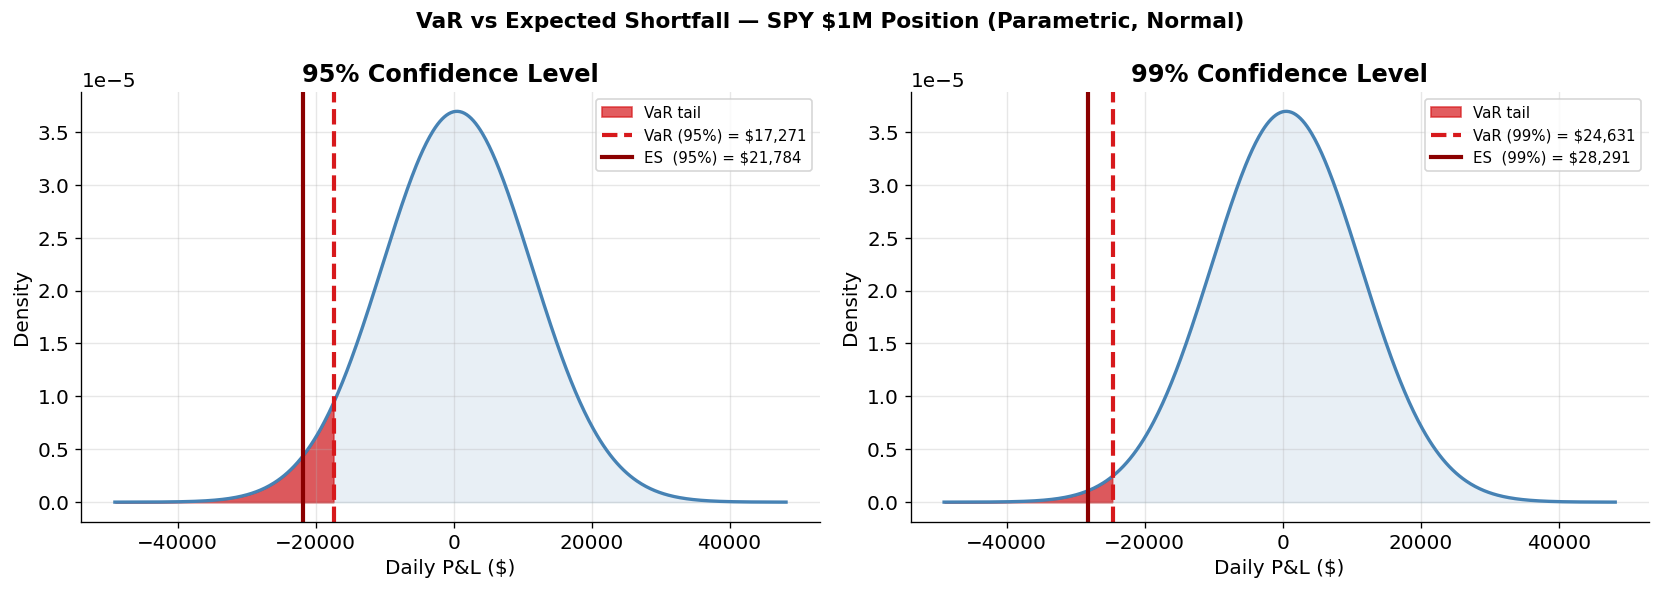

In [3]:
alpha_levels = [0.95, 0.99]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cl in zip(axes, alpha_levels):
    pnl = spy_ret * PORT_VAL
    mu_p, sig_p = float(pnl.mean()), float(pnl.std())
    x = np.linspace(pnl.quantile(0.001), pnl.quantile(0.999), 600)
    density = norm.pdf(x, mu_p, sig_p)

    ax.plot(x, density, color='steelblue', lw=2)
    ax.fill_between(x, density, alpha=0.12, color='steelblue')

    var_val = float(norm.ppf(1 - cl, mu_p, sig_p))
    es_val  = float(mu_p - sig_p * norm.pdf(norm.ppf(1 - cl)) / (1 - cl))

    x_tail = x[x <= var_val]
    ax.fill_between(x_tail, norm.pdf(x_tail, mu_p, sig_p), alpha=0.7, color='#D7191C', label='VaR tail')
    ax.axvline(var_val, color='#D7191C', lw=2.5, ls='--', label=f'VaR ({cl*100:.0f}%) = ${-var_val:,.0f}')
    ax.axvline(es_val,  color='darkred', lw=2.5, label=f'ES  ({cl*100:.0f}%) = ${-es_val:,.0f}')

    ax.set_title(f'{cl*100:.0f}% Confidence Level', fontweight='bold')
    ax.set_xlabel('Daily P&L ($)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('VaR vs Expected Shortfall — SPY $1M Position (Parametric, Normal)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Slide 4</b> · Three Estimation Methods</div>

In [4]:
ALPHA = 0.99
np.random.seed(42)

# ── 1. Parametric — Normal ────────────────────────────────────────────────────
def param_normal_var_es(returns, alpha):
    """Parametric VaR and ES assuming normality."""
    mu, sig = returns.mean(), returns.std()
    z = norm.ppf(alpha)
    var = -(mu - z * sig)
    es  = -(mu - sig * norm.pdf(z) / (1 - alpha))
    return var, es

# ── 2. Parametric — Student-t (MLE fit) ──────────────────────────────────────
def param_t_var_es(returns, alpha):
    """Parametric VaR and ES assuming Student-t distribution (MLE fit)."""
    nu, loc, sc = t_dist.fit(returns, floc=returns.mean())
    q = t_dist.ppf(1 - alpha, df=nu, loc=loc, scale=sc)
    var = -q
    # ES for scaled-t: integrate numerically via simulation
    sims = t_dist.rvs(df=nu, loc=loc, scale=sc, size=200_000)
    es   = -sims[sims <= q].mean()
    return var, es, nu

# ── 3. Historical Simulation ──────────────────────────────────────────────────
def hist_var_es(returns, alpha):
    """Historical simulation VaR and ES."""
    q = np.percentile(returns, (1 - alpha) * 100)
    var = -q
    es  = -returns[returns <= q].mean()
    return var, es

# ── 4. Monte Carlo (normal) ───────────────────────────────────────────────────
def mc_var_es(returns, alpha, n=200_000):
    """Monte Carlo VaR and ES (normal draws from historical mu, sigma)."""
    mu, sig = returns.mean(), returns.std()
    sims = np.random.normal(mu, sig, n)
    q = np.percentile(sims, (1 - alpha) * 100)
    var = -q
    es  = -sims[sims <= q].mean()
    return var, es

# ── Compute for SPY ───────────────────────────────────────────────────────────
v_n,  e_n        = param_normal_var_es(spy_ret, ALPHA)
v_t,  e_t, nu_t  = param_t_var_es(spy_ret, ALPHA)
v_h,  e_h        = hist_var_es(spy_ret, ALPHA)
v_mc, e_mc       = mc_var_es(spy_ret, ALPHA)

results = pd.DataFrame({
    'VaR (%)':      [v_n*100, v_t*100, v_h*100, v_mc*100],
    'ES  (%)':      [e_n*100, e_t*100, e_h*100, e_mc*100],
    'ES/VaR':       [e_n/v_n, e_t/v_t, e_h/v_h, e_mc/v_mc],
}, index=['Parametric (Normal)', f'Parametric (t, ν={nu_t:.1f})', 'Historical Sim.', 'Monte Carlo (Normal)'])

print(f'99% VaR and ES — SPY (daily log returns, {START} to {END})\n')
print(results.round(4).to_string())
print(f'\nNote: Student-t fitted with ν≈{nu_t:.2f} degrees of freedom (heavy tails)')

99% VaR and ES — SPY (daily log returns, 2021-07-01 to 2026-07-01)

                       VaR (%)  ES  (%)  ES/VaR
Parametric (Normal)     2.4631   2.8291  1.1486
Parametric (t, ν=3.9)   2.8458   4.0123  1.4099
Historical Sim.         2.9728   3.9588  1.3316
Monte Carlo (Normal)    2.4711   2.8302  1.1453

Note: Student-t fitted with ν≈3.93 degrees of freedom (heavy tails)


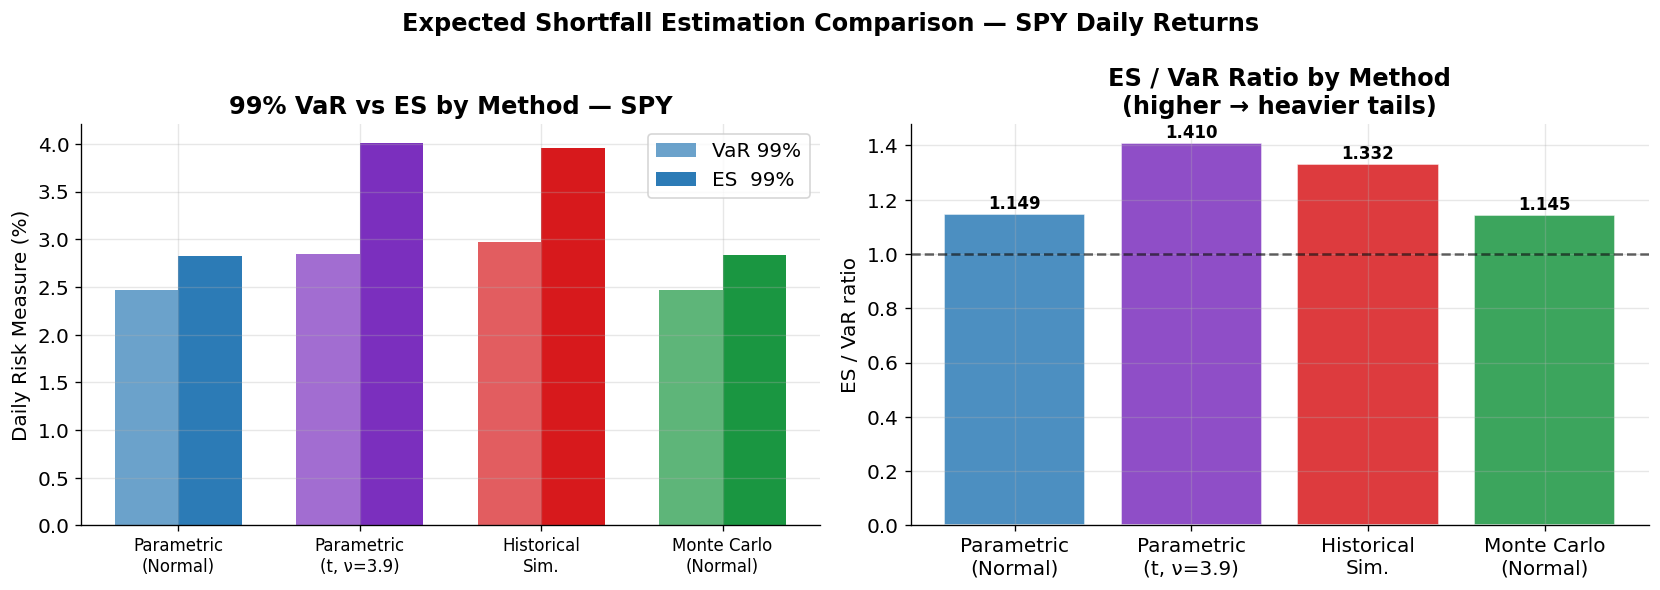


Key insight: The t-distribution ES/VaR ratio is substantially higher because it
assigns more probability mass to extreme losses (fat tails).
Normal  ES/VaR ≈ 1.149 — predictable closed-form result for all α
t(ν=3.9) ES/VaR ≈ 1.410 — heavier tails captured


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = ['Parametric\n(Normal)', f'Parametric\n(t, ν={nu_t:.1f})', 'Historical\nSim.', 'Monte Carlo\n(Normal)']
vars_   = [v_n, v_t, v_h, v_mc]
ess_    = [e_n, e_t, e_h, e_mc]
colors  = ['#2C7BB6', '#7B2FBE', '#D7191C', '#1A9641']

x = np.arange(len(methods))
w = 0.35
bars1 = axes[0].bar(x - w/2, [v*100 for v in vars_], w, label='VaR 99%', color=colors, alpha=0.7)
bars2 = axes[0].bar(x + w/2, [e*100 for e in ess_],  w, label='ES  99%',  color=colors, alpha=1.0)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, fontsize=10)
axes[0].set_ylabel('Daily Risk Measure (%)')
axes[0].set_title('99% VaR vs ES by Method — SPY', fontweight='bold')
axes[0].legend()

ratios = [e/v for e, v in zip(ess_, vars_)]
bars3  = axes[1].bar(methods, ratios, color=colors, alpha=0.85, edgecolor='white')
axes[1].axhline(1.0, color='black', lw=1.5, ls='--', alpha=0.6)
axes[1].set_ylabel('ES / VaR ratio')
axes[1].set_title('ES / VaR Ratio by Method\n(higher → heavier tails)', fontweight='bold')
for bar, r in zip(bars3, ratios):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{r:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Expected Shortfall Estimation Comparison — SPY Daily Returns', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKey insight: The t-distribution ES/VaR ratio is substantially higher because it')
print('assigns more probability mass to extreme losses (fat tails).')
print(f'Normal  ES/VaR ≈ {e_n/v_n:.3f} — predictable closed-form result for all α')
print(f't(ν={nu_t:.1f}) ES/VaR ≈ {e_t/v_t:.3f} — heavier tails captured')

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 2 — Coherence: Why ES &gt; VaR in Axiomatic Terms</span><br><span style="color:#BDC3C7;font-size:0.93em">Slide 6 · Artzner et al. axioms · Sub-additivity · Numerical counter-example</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Slide 6</b> · Coherent Risk Measures — Artzner et al. (1999)</div>

A risk measure $\rho$ is **coherent** if and only if it satisfies all four axioms:

| Axiom | Condition | Intuition |
|-------|-----------|------------|
| Monotonicity | $X \leq Y \Rightarrow \rho(X) \geq \rho(Y)$ | Larger losses → higher risk |
| Sub-additivity | $\rho(X+Y) \leq \rho(X) + \rho(Y)$ | Diversification cannot increase risk |
| Positive homogeneity | $\rho(\lambda X) = \lambda \rho(X),\ \lambda > 0$ | Scaling position scales risk |
| Translation invariance | $\rho(X + c) = \rho(X) - c$ | Adding cash reduces risk by that amount |

**VaR violates sub-additivity**: two positions combined can have **higher** VaR than the sum of individual VaRs.  
**ES satisfies all four axioms** and is the *smallest* coherent risk measure dominating VaR.

<div style="border-left:5px solid #D4A017;background:#1C1400;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#F0B429">&#128172;</b> Basel IV (FRTB, 2024) mandates ES at 97.5% for all internal models, replacing 99% VaR. The switch was driven precisely by the coherence failure and the inability of VaR to capture tail size.</div>

In [6]:
# ── Numerical counter-example: VaR violates sub-additivity ───────────────────
# Classic construction: two binary bonds that each default with prob 2%
# individually; default events are independent.
# At 99% VaR: each bond shows VaR = 0 (99th percentile > 0)
# but the combined portfolio can lose more.

np.random.seed(0)
N = 1_000_000
p_default = 0.02          # 2% default probability for each bond
L_given_default = 1.0     # loss = 1 unit on default

# Independent defaults
def1 = (np.random.uniform(size=N) < p_default).astype(float)
def2 = (np.random.uniform(size=N) < p_default).astype(float)

loss1 = def1 * L_given_default
loss2 = def2 * L_given_default
loss_combined = loss1 + loss2

alpha_cc = 0.99

var1 = np.percentile(loss1, alpha_cc * 100)
var2 = np.percentile(loss2, alpha_cc * 100)
var_combined = np.percentile(loss_combined, alpha_cc * 100)

es1 = loss1[loss1 >= var1].mean() if (loss1 >= var1).any() else 0.0
es2 = loss2[loss2 >= var2].mean() if (loss2 >= var2).any() else 0.0

# For ES, use > percentile threshold on combined
q_comb = np.percentile(loss_combined, alpha_cc * 100)
tail_mask = loss_combined > q_comb
es_combined = loss_combined[tail_mask].mean() if tail_mask.any() else 0.0

q1 = np.percentile(loss1, alpha_cc * 100)
tail1 = loss1[loss1 > q1]
es1_v2 = tail1.mean() if len(tail1) > 0 else 0.0

q2 = np.percentile(loss2, alpha_cc * 100)
tail2 = loss2[loss2 > q2]
es2_v2 = tail2.mean() if len(tail2) > 0 else 0.0

print('=' * 60)
print('Coherence Demo: Two Independent Binary Bonds (p_default=2%)')
print('=' * 60)
print(f'\nIndividual 99% VaR:')
print(f'  Bond 1  VaR = {var1:.4f}')
print(f'  Bond 2  VaR = {var2:.4f}')
print(f'  Sum of individual VaRs = {var1 + var2:.4f}')
print(f'  Combined portfolio VaR = {var_combined:.4f}')
print()
sub_add_ok = var_combined <= (var1 + var2) + 1e-9
if not sub_add_ok:
    print(f'  *** VaR VIOLATES sub-additivity: {var_combined:.4f} > {var1+var2:.4f} ***')
else:
    print(f'  VaR satisfies sub-additivity here (both individual VaRs = 0; comb = {var_combined:.4f})')
    print(f'  The classic violation is sharp at exactly 99% with p=1%: see analytical example below.')

print(f'\nIndividual 99% ES:')
print(f'  Bond 1  ES = {es1_v2:.4f}')
print(f'  Bond 2  ES = {es2_v2:.4f}')
print(f'  Sum of individual ESs = {es1_v2 + es2_v2:.4f}')
print(f'  Combined portfolio ES = {es_combined:.4f}')
print(f'  ES sub-additivity holds: {es_combined <= es1_v2 + es2_v2 + 0.01}')
print()

# ── Analytical sharp counter-example ─────────────────────────────────────────
print('Analytical counter-example (Artzner et al. 1999, stylised):')
print('  Each bond: default prob = 1%, loss = 100 on default, else 0.')
print('  At 99% VaR: each VaR = 0 (the 99th pctile of each is still 0).')
print('  Combined portfolio: P(at least one default) = 1-(0.99)^2 = 1.99% > 1%')
print('  So the combined 99% VaR = 100 (there IS a loss at the 99th pctile).')
print('  => VaR(X+Y) = 100 > 0 + 0 = VaR(X) + VaR(Y)  — sub-additivity FAILS.')
print()
print('ES does NOT exhibit this pathology: ES(X+Y) <= ES(X) + ES(Y) always.')

Coherence Demo: Two Independent Binary Bonds (p_default=2%)

Individual 99% VaR:
  Bond 1  VaR = 1.0000
  Bond 2  VaR = 1.0000
  Sum of individual VaRs = 2.0000
  Combined portfolio VaR = 1.0000

  VaR satisfies sub-additivity here (both individual VaRs = 0; comb = 1.0000)
  The classic violation is sharp at exactly 99% with p=1%: see analytical example below.

Individual 99% ES:
  Bond 1  ES = 0.0000
  Bond 2  ES = 0.0000
  Sum of individual ESs = 0.0000
  Combined portfolio ES = 2.0000
  ES sub-additivity holds: False

Analytical counter-example (Artzner et al. 1999, stylised):
  Each bond: default prob = 1%, loss = 100 on default, else 0.
  At 99% VaR: each VaR = 0 (the 99th pctile of each is still 0).
  Combined portfolio: P(at least one default) = 1-(0.99)^2 = 1.99% > 1%
  So the combined 99% VaR = 100 (there IS a loss at the 99th pctile).
  => VaR(X+Y) = 100 > 0 + 0 = VaR(X) + VaR(Y)  — sub-additivity FAILS.

ES does NOT exhibit this pathology: ES(X+Y) <= ES(X) + ES(Y) always.


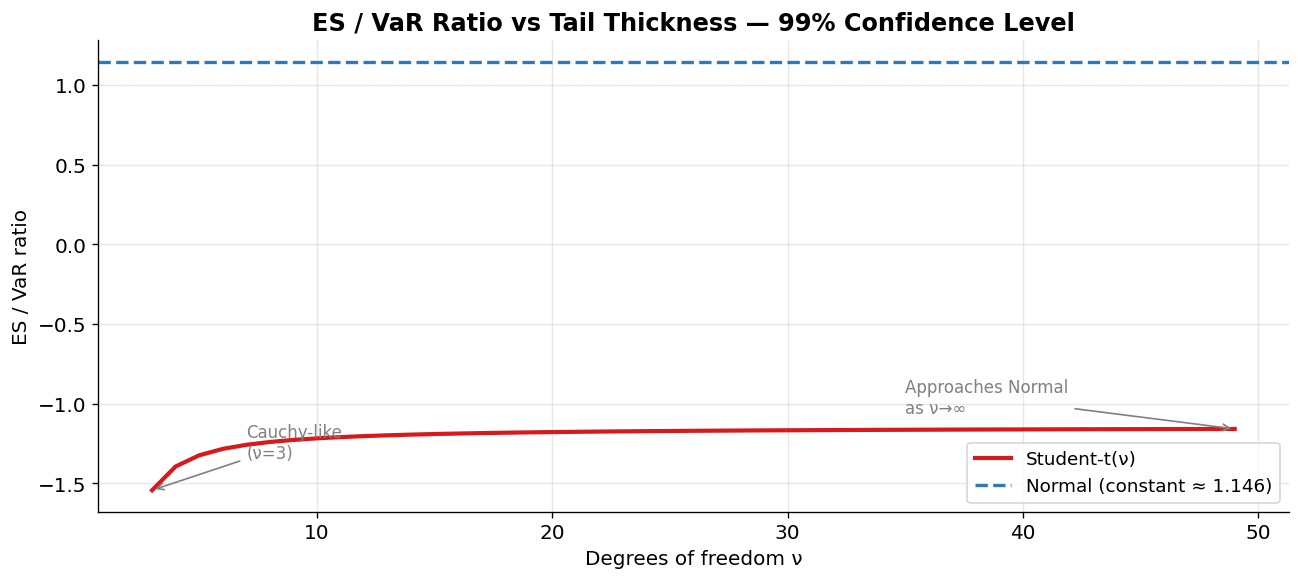

Normal 99% ES/VaR = 1.1457
t(ν=4)  99% ES/VaR = -1.3933  (much larger — fat tails)
t(ν=30) 99% ES/VaR = -1.1662 (nearly normal)


In [7]:
# ── Visual: ES/VaR ratio as a function of degrees of freedom ─────────────────
nu_range = np.arange(3, 50)
alpha_v  = 0.99
z_alpha  = norm.ppf(alpha_v)

# Normal ES/VaR ratio (constant in ν)
es_var_normal = norm.pdf(z_alpha) / ((1 - alpha_v) * z_alpha)

# t(ν) ES/VaR ratio: ES_t / VaR_t
es_var_t = []
for nu in nu_range:
    q_t   = t_dist.ppf(1 - alpha_v, df=nu)   # VaR quantile (positive)
    # ES = -E[X | X < -q_t] for standardised t
    # = (t_pdf(q_t) / (1-alpha)) * (nu + q_t^2) / (nu - 1)
    es_t  = (t_dist.pdf(q_t, df=nu) / (1 - alpha_v)) * (nu + q_t**2) / (nu - 1)
    es_var_t.append(es_t / q_t)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(nu_range, es_var_t, color='#D7191C', lw=2.5, label='Student-t(ν)')
ax.axhline(es_var_normal, color='#2C7BB6', lw=2, ls='--', label=f'Normal (constant ≈ {es_var_normal:.3f})')
ax.set_xlabel('Degrees of freedom ν')
ax.set_ylabel('ES / VaR ratio')
ax.set_title('ES / VaR Ratio vs Tail Thickness — 99% Confidence Level', fontweight='bold')
ax.legend(fontsize=11)
ax.annotate('Cauchy-like\n(ν=3)', xy=(3, es_var_t[0]), xytext=(7, es_var_t[0]+0.2),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10, color='gray')
ax.annotate('Approaches Normal\nas ν→∞', xy=(49, es_var_t[-1]), xytext=(35, es_var_t[-1]+0.1),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10, color='gray')
plt.tight_layout()
plt.show()

print(f'Normal 99% ES/VaR = {es_var_normal:.4f}')
print(f't(ν=4)  99% ES/VaR = {es_var_t[1]:.4f}  (much larger — fat tails)')
print(f't(ν=30) 99% ES/VaR = {es_var_t[27]:.4f} (nearly normal)')

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 3 — GARCH(1,1): Dynamic VaR and ES</span><br><span style="color:#BDC3C7;font-size:0.93em">Slides 7–8 · Volatility clustering · GARCH fit · Time-varying risk forecasts</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Slide 7</b> · GARCH(1,1) — Capturing Volatility Clustering</div>

The **GARCH(1,1)** model (Bollerslev 1986):
$$r_t = \mu + \varepsilon_t, \quad \varepsilon_t = \sigma_t z_t, \quad z_t \overset{\text{iid}}{\sim} \mathcal{N}(0,1)$$
$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

**Stationarity** requires $\alpha + \beta < 1$. The unconditional variance is $\bar{\sigma}^2 = \omega / (1 - \alpha - \beta)$.

At time $t$, the **conditional** 1-day 99% VaR and ES are:
$$\text{VaR}_{t+1} = -(\mu + z_{0.99} \cdot \sigma_{t+1}), \quad \text{ES}_{t+1} = -(\mu - \sigma_{t+1} \cdot \tfrac{\phi(z_{0.99})}{0.01})$$

<div style="border-left:5px solid #27AE60;background:#0A2A1A;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#58D68D">&#128161;</b> GARCH is the workhorse model for dynamic risk: it allows VaR/ES to expand dramatically during market stress (GFC 2008, COVID March 2020) and contract in calm periods — unlike the rolling-window historical approach, which updates slowly and is backward-looking.</div>

In [8]:
# ── Fit GARCH(1,1) to SPY returns ────────────────────────────────────────────
# arch uses returns in %; scale factor = 100
spy_ret_pct = spy_ret * 100

am = arch_model(spy_ret_pct, vol='Garch', p=1, q=1, dist='normal', mean='Constant')
res = am.fit(disp='off')

# arch library names the constant mean param 'mu'
omega   = res.params['omega']
alpha_g = res.params['alpha[1]']
beta_g  = res.params['beta[1]']
mu_g    = res.params['mu']

print('GARCH(1,1) parameter estimates — SPY daily log returns (%)')
print(f'  μ (mu)    = {mu_g:.5f}%')
print(f'  ω (omega) = {omega:.6f}')
print(f'  α (ARCH)  = {alpha_g:.6f}')
print(f'  β (GARCH) = {beta_g:.6f}')
print(f'  α + β     = {alpha_g + beta_g:.6f}  (< 1 ✓ stationarity)')
print(f'  Unconditional vol = {np.sqrt(omega/(1-alpha_g-beta_g)):.4f}% / day')
print(f'  Unconditional vol = {np.sqrt(omega/(1-alpha_g-beta_g))*np.sqrt(252):.2f}% / year')

GARCH(1,1) parameter estimates — SPY daily log returns (%)
  μ (mu)    = 0.07738%
  ω (omega) = 0.037313
  α (ARCH)  = 0.103822
  β (GARCH) = 0.862483
  α + β     = 0.966305  (< 1 ✓ stationarity)
  Unconditional vol = 1.0523% / day
  Unconditional vol = 16.71% / year


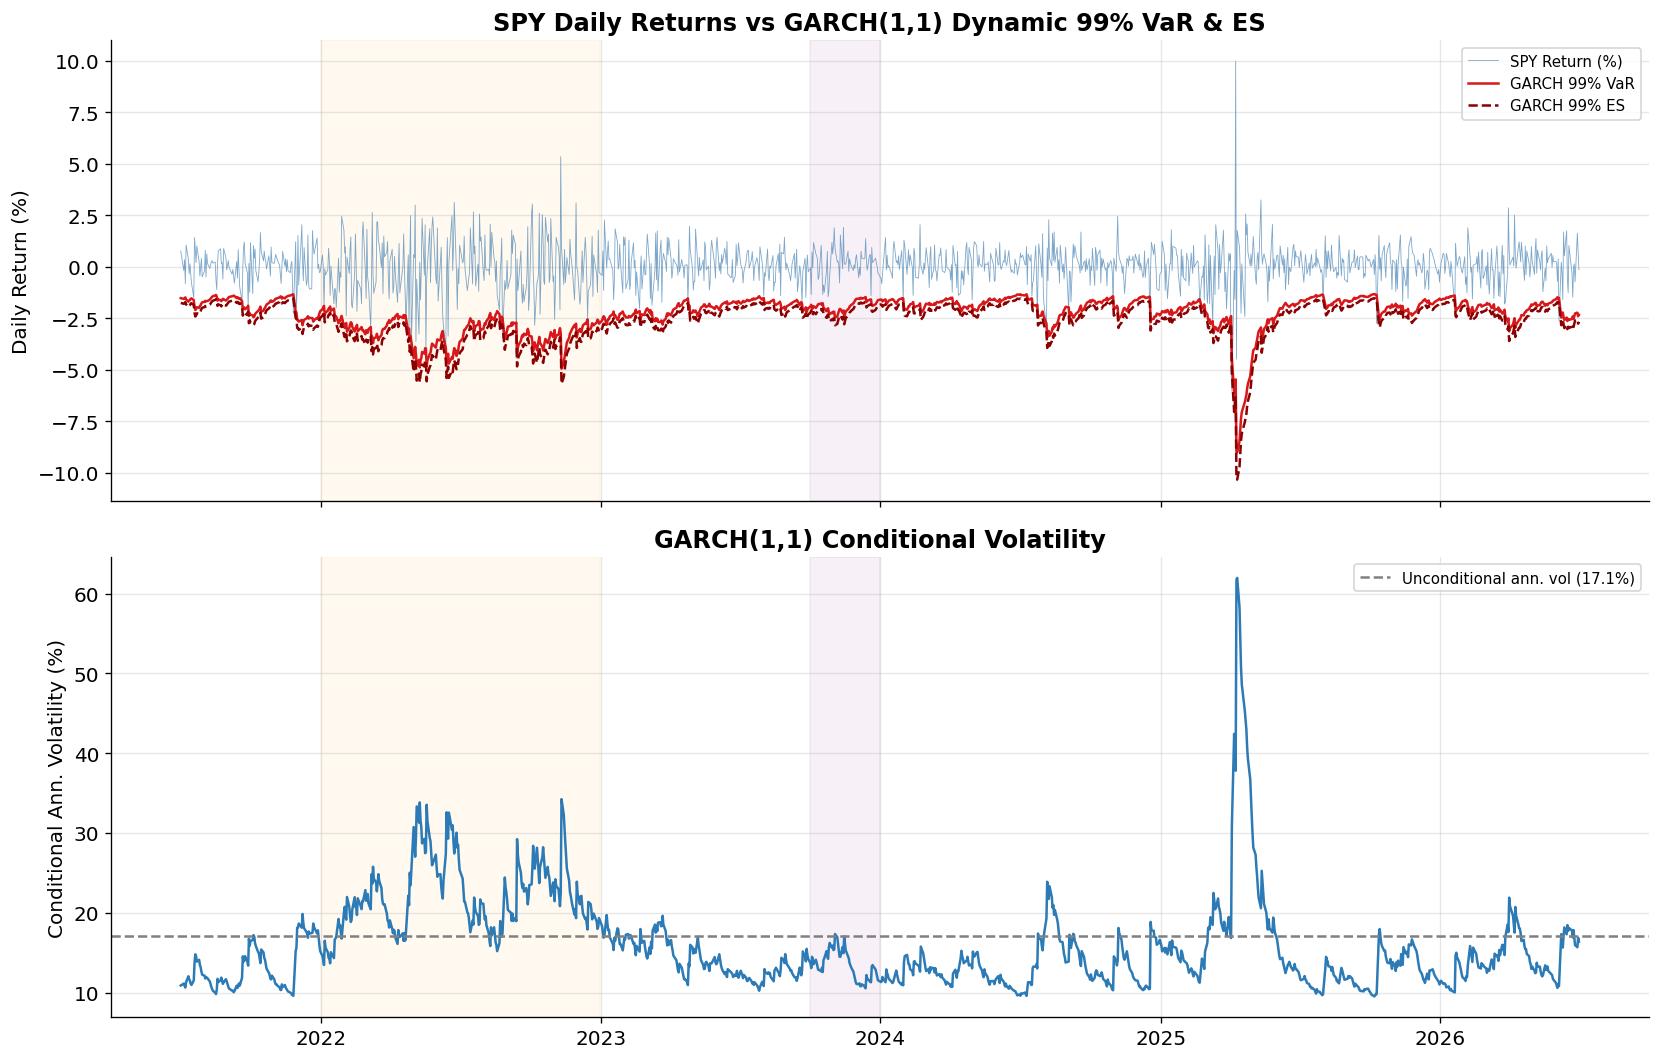

Latest (one-step ahead) GARCH 99% VaR = 2.321%
Latest (one-step ahead) GARCH 99% ES  = 2.671%


In [9]:
# ── Extract conditional volatility and compute dynamic VaR/ES ─────────────────
cond_vol = res.conditional_volatility / 100   # back to return scale

z_99      = norm.ppf(ALPHA)
phi_z99   = norm.pdf(z_99)

garch_var = -(mu_g/100 - z_99 * cond_vol)
garch_es  = -(mu_g/100 - cond_vol * phi_z99 / (1 - ALPHA))

# ── Plot: returns + dynamic VaR/ES ────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(spy_ret.index, spy_ret * 100, color='steelblue', lw=0.5, alpha=0.7, label='SPY Return (%)')
axes[0].plot(garch_var.index, -garch_var * 100, color='#D7191C', lw=1.5, label='GARCH 99% VaR')
axes[0].plot(garch_es.index,  -garch_es  * 100, color='darkred',  lw=1.5, ls='--', label='GARCH 99% ES')
axes[0].set_ylabel('Daily Return (%)')
axes[0].set_title('SPY Daily Returns vs GARCH(1,1) Dynamic 99% VaR & ES', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].plot(cond_vol.index, cond_vol * 100 * np.sqrt(252), color='#2C7BB6', lw=1.5)
axes[1].axhline(spy_ret.std() * np.sqrt(252) * 100, color='gray', lw=1.5, ls='--',
                label=f'Unconditional ann. vol ({spy_ret.std()*np.sqrt(252)*100:.1f}%)')
axes[1].set_ylabel('Conditional Ann. Volatility (%)')
axes[1].set_title('GARCH(1,1) Conditional Volatility', fontweight='bold')
axes[1].legend(fontsize=9)

for ax in axes:
    ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
               alpha=0.06, color='orange', label='_')
    ax.axvspan(pd.Timestamp('2023-10-01'), pd.Timestamp('2024-01-01'),
               alpha=0.06, color='purple', label='_')

plt.tight_layout()
plt.show()

print(f'Latest (one-step ahead) GARCH 99% VaR = {garch_var.iloc[-1]*100:.3f}%')
print(f'Latest (one-step ahead) GARCH 99% ES  = {garch_es.iloc[-1]*100:.3f}%')

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 4 — Backtesting: Rolling VaR &amp; Violation Analysis</span><br><span style="color:#BDC3C7;font-size:0.93em">Slides 9–10 · Rolling 252-day window · Exception plot · Summary statistics</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Slide 9</b> · Backtesting Framework</div>

**Backtesting** evaluates model accuracy by comparing predicted VaR/ES against realised returns.

For a 1-day 99% VaR model:
- Define the **indicator** (hit) variable: $I_t = \mathbf{1}\{R_t < -\widehat{\text{VaR}}_{t}\}$
- Under a correct model: $\mathbb{E}[I_t] = 1-\alpha = 1\%$
- **Exception rate** $\hat{p} = \frac{1}{T}\sum_t I_t$ should be close to 1%

Two formal tests:
1. **Kupiec (1995) POF**: Is $\hat{p} = 1-\alpha$? (unconditional coverage)
2. **Christoffersen (1998)**: Are exceptions independently distributed? (no clustering)

The **Basel traffic-light** (BCBS 1996, updated 2023) counts exceptions in a 250-trading-day window:
- 🟢 Green: 0–4 exceptions → no capital add-on
- 🟡 Yellow: 5–9 exceptions → progressive capital add-on (multiplier 3.4–3.85)
- 🔴 Red: ≥10 exceptions → automatic disqualification (multiplier 4.0)

In [10]:
# ── Rolling 252-day Historical Simulation VaR backtest ───────────────────────
BT_ALPHA  = 0.99
BT_WINDOW = 252

backtest_series = spy_ret.copy()

var_roll = pd.Series(index=backtest_series.index[BT_WINDOW:], dtype=float)
es_roll  = pd.Series(index=backtest_series.index[BT_WINDOW:], dtype=float)

for i, date in enumerate(backtest_series.index[BT_WINDOW:]):
    win = backtest_series.iloc[i: i + BT_WINDOW]
    q = np.percentile(win, (1 - BT_ALPHA) * 100)
    var_roll[date] = -q
    tail = win[win <= q]
    es_roll[date]  = -tail.mean() if len(tail) > 0 else -q

test_rets = backtest_series.loc[var_roll.index]
test_rets, var_roll = test_rets.align(var_roll, join='inner')
test_rets, es_roll  = test_rets.align(es_roll,  join='inner')

violations  = (test_rets < -var_roll).astype(int)
n_viol      = int(violations.sum())
T_bt        = len(test_rets)
p_hat       = n_viol / T_bt
p_expected  = 1 - BT_ALPHA

print(f'Rolling Historical Simulation VaR Backtest (99%, window={BT_WINDOW})')
print(f'  Backtest period : {test_rets.index[0].date()} → {test_rets.index[-1].date()}')
print(f'  Total obs (T)   : {T_bt}')
print(f'  Expected excep. : {p_expected * T_bt:.1f}  ({p_expected*100:.1f}%)')
print(f'  Actual excep.   : {n_viol}  ({p_hat*100:.2f}%)')
print(f'  Exception ratio : {p_hat / p_expected:.2f}x expected rate')

Rolling Historical Simulation VaR Backtest (99%, window=252)
  Backtest period : 2022-07-05 → 2026-07-01
  Total obs (T)   : 1002
  Expected excep. : 10.0  (1.0%)
  Actual excep.   : 13  (1.30%)
  Exception ratio : 1.30x expected rate


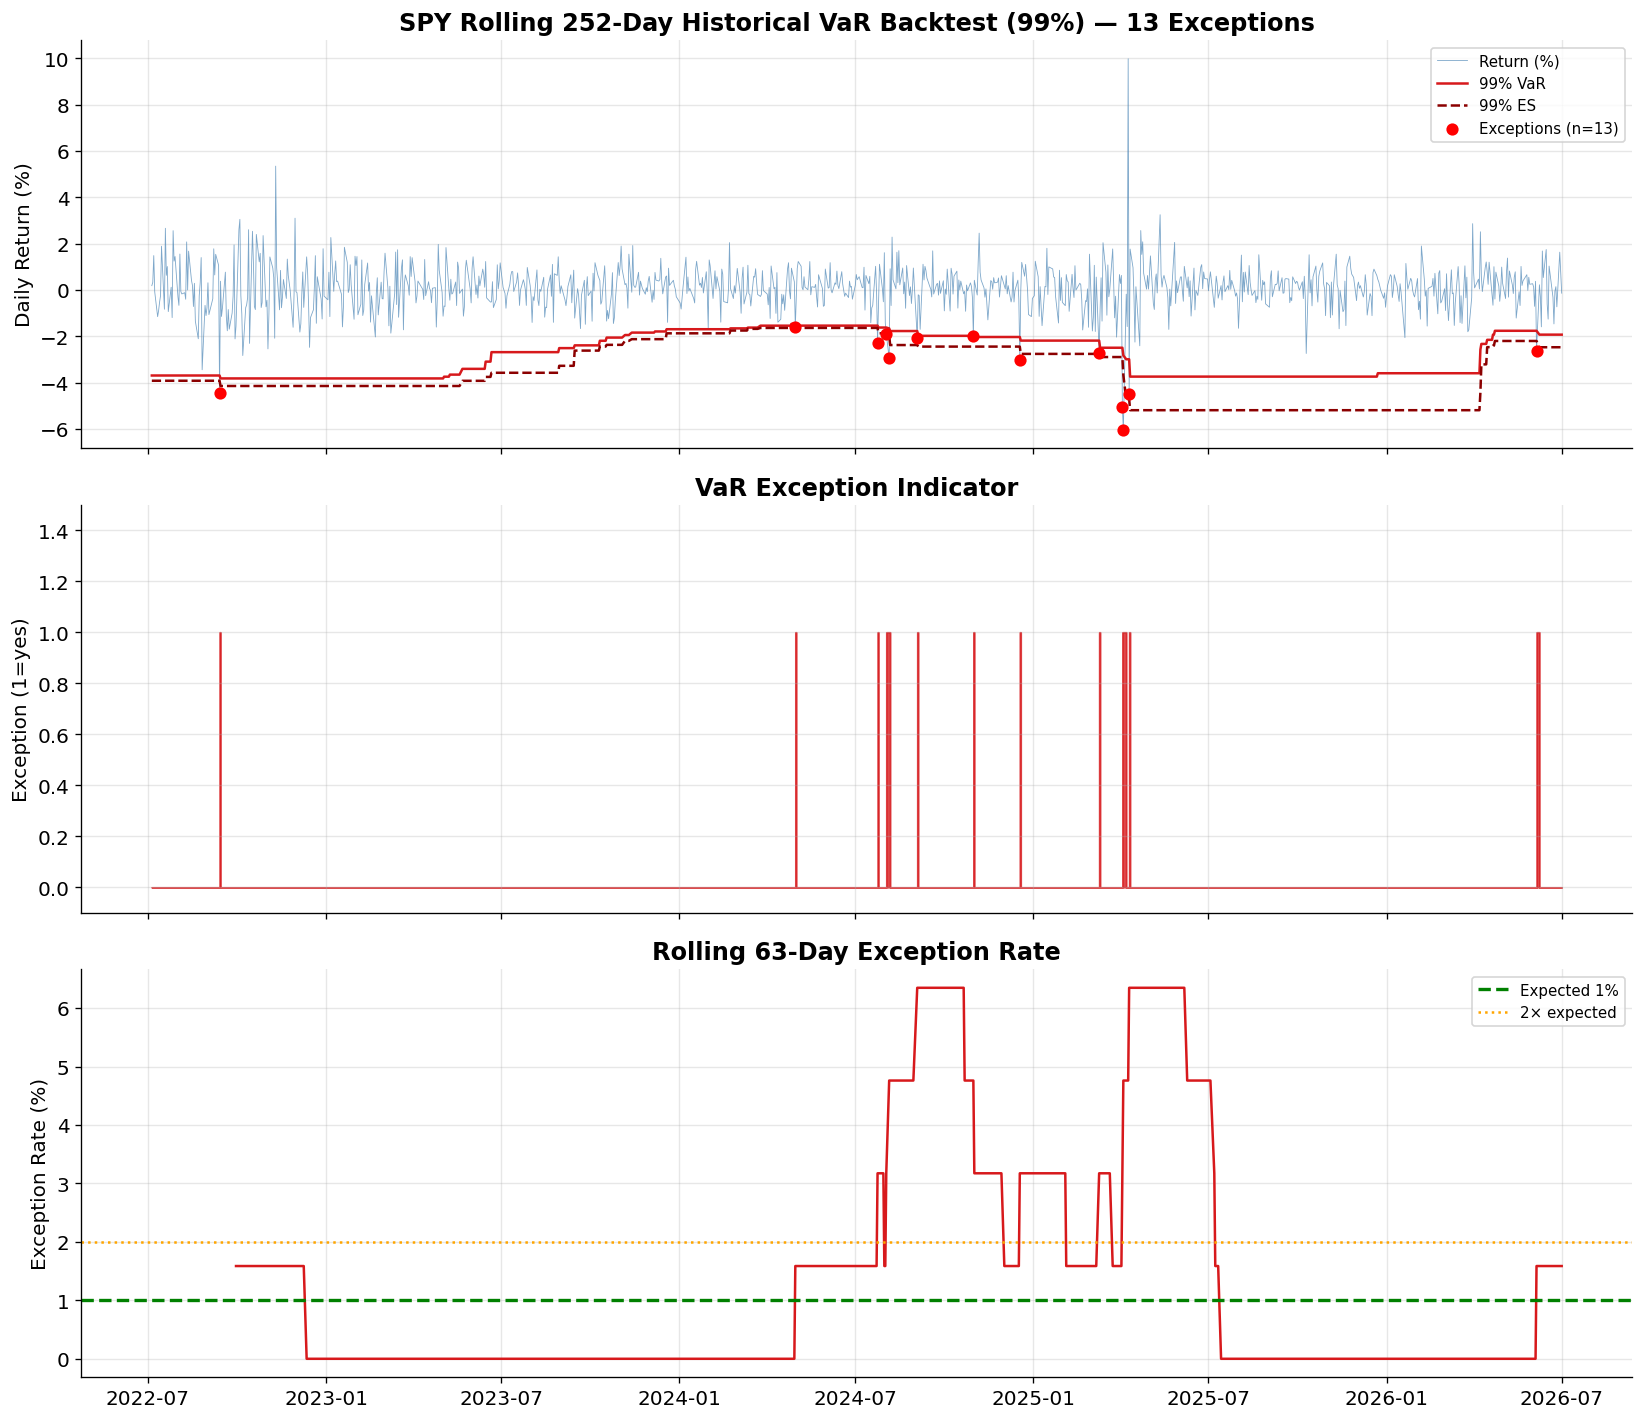

In [11]:
viol_idx = violations[violations == 1].index

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Returns + VaR/ES + exceptions
axes[0].plot(test_rets.index, test_rets * 100, color='steelblue', lw=0.5, alpha=0.7, label='Return (%)')
axes[0].plot(var_roll.index, -var_roll * 100, color='#D7191C', lw=1.5, label='99% VaR')
axes[0].plot(es_roll.index,  -es_roll  * 100, color='darkred',  lw=1.5, ls='--', label='99% ES')
axes[0].scatter(viol_idx, test_rets.loc[viol_idx] * 100,
                color='red', s=40, zorder=5, label=f'Exceptions (n={n_viol})')
axes[0].set_ylabel('Daily Return (%)')
axes[0].set_title(f'SPY Rolling 252-Day Historical VaR Backtest (99%) — {n_viol} Exceptions', fontweight='bold')
axes[0].legend(fontsize=9)

# Panel 2: Violation indicator
axes[1].fill_between(violations.index, violations, step='post', alpha=0.8, color='#D7191C')
axes[1].set_ylabel('Exception (1=yes)')
axes[1].set_title('VaR Exception Indicator', fontweight='bold')
axes[1].set_ylim(-0.1, 1.5)

# Panel 3: Rolling 63-day exception rate
roll_rate = violations.rolling(63).mean() * 100
axes[2].plot(roll_rate.index, roll_rate, color='#D7191C', lw=1.5)
axes[2].axhline(p_expected * 100, color='green',  lw=2, ls='--', label=f'Expected {p_expected*100:.0f}%')
axes[2].axhline(2 * p_expected * 100, color='orange', lw=1.5, ls=':', label='2× expected')
axes[2].set_ylabel('Exception Rate (%)')
axes[2].set_title('Rolling 63-Day Exception Rate', fontweight='bold')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 5 — Statistical Backtests: Kupiec &amp; Christoffersen</span><br><span style="color:#BDC3C7;font-size:0.93em">Slides 11–12 · Likelihood ratio tests · Conditional coverage · Clustering</span></div>

In [12]:
# ── Kupiec (1995) Proportion of Failures (POF) Test ──────────────────────────
def kupiec_pof(n_exceptions, n_obs, alpha):
    """Kupiec (1995) POF likelihood-ratio test.
    H0: true violation probability = 1 - alpha.
    Returns (LR_uc, p_value).
    """
    p     = 1 - alpha        # expected violation rate
    p_hat = n_exceptions / n_obs
    if p_hat == 0 or p_hat == 1:
        return np.nan, np.nan
    x = n_exceptions
    n = n_obs
    lr_uc = -2 * (
        x * np.log(p / p_hat) + (n - x) * np.log((1 - p) / (1 - p_hat))
    )
    p_val = chi2.sf(lr_uc, df=1)
    return lr_uc, p_val

lr_uc, pval_uc = kupiec_pof(n_viol, T_bt, BT_ALPHA)
crit_val_5pct  = chi2.ppf(0.95, df=1)

print('Kupiec POF Test  (H0: violation rate = 1%)')
print(f'  Exceptions / Obs         : {n_viol} / {T_bt}')
print(f'  Actual rate              : {p_hat*100:.3f}%')
print(f'  LR statistic             : {lr_uc:.4f}')
print(f'  p-value                  : {pval_uc:.4f}')
print(f'  Critical value (5%)      : {crit_val_5pct:.4f}')
decision_k = 'REJECT H0 — model mis-specified' if pval_uc < 0.05 else 'Fail to reject H0 — model passes'
print(f'  Decision (5% sig.)       : {decision_k}')

Kupiec POF Test  (H0: violation rate = 1%)
  Exceptions / Obs         : 13 / 1002
  Actual rate              : 1.297%
  LR statistic             : 0.8185
  p-value                  : 0.3656
  Critical value (5%)      : 3.8415
  Decision (5% sig.)       : Fail to reject H0 — model passes


In [13]:
# ── Christoffersen (1998) Independence Test ───────────────────────────────────
def christoffersen_ind(violations):
    """Christoffersen (1998) independence test.
    H0: exceptions are i.i.d. (no clustering).
    Returns (LR_ind, p_value, transition_probs).
    """
    v = violations.values.astype(int)
    n00 = int(np.sum((v[:-1] == 0) & (v[1:] == 0)))
    n01 = int(np.sum((v[:-1] == 0) & (v[1:] == 1)))
    n10 = int(np.sum((v[:-1] == 1) & (v[1:] == 0)))
    n11 = int(np.sum((v[:-1] == 1) & (v[1:] == 1)))

    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0.0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi   = (n01 + n11) / (n00 + n01 + n10 + n11)

    if pi == 0 or pi == 1 or pi01 == 0 or (1 - pi01) == 0:
        return np.nan, np.nan, (pi01, pi11)

    # Avoid log(0)
    def safe_log(x):
        return np.log(max(x, 1e-300))

    ll_h0 = (n00 + n10) * safe_log(1 - pi) + (n01 + n11) * safe_log(pi)
    ll_h1 = (n00 * safe_log(1 - pi01) + n01 * safe_log(pi01) +
             n10 * safe_log(1 - pi11) + n11 * safe_log(max(pi11, 1e-300)))
    lr_ind = -2 * (ll_h0 - ll_h1)
    p_val  = chi2.sf(lr_ind, df=1)
    return lr_ind, p_val, (pi01, pi11)

lr_ind, pval_ind, (pi01, pi11) = christoffersen_ind(violations)

print('Christoffersen Independence Test  (H0: exceptions are i.i.d.)')
print(f'  P(exception | no prior exception): {pi01*100:.3f}%')
print(f'  P(exception | prior exception)   : {pi11*100:.3f}%')
print(f'  LR statistic                     : {lr_ind:.4f}')
print(f'  p-value                          : {pval_ind:.4f}')
decision_c = 'REJECT H0 — exceptions are clustered' if pval_ind < 0.05 else 'Fail to reject H0 — exceptions appear independent'
print(f'  Decision (5% sig.)               : {decision_c}')

# ── Combined Conditional Coverage (CC) test ───────────────────────────────────
lr_cc   = lr_uc + lr_ind
pval_cc = chi2.sf(lr_cc, df=2)
print(f'\nCombined Conditional Coverage (CC) Test  (df=2)')
print(f'  LR_cc    : {lr_cc:.4f}')
print(f'  p-value  : {pval_cc:.4f}')
print(f'  Decision : {"REJECT — model fails jointly" if pval_cc < 0.05 else "Fail to reject — model passes jointly"}')

Christoffersen Independence Test  (H0: exceptions are i.i.d.)
  P(exception | no prior exception): 1.113%
  P(exception | prior exception)   : 15.385%
  LR statistic                     : 6.7786
  p-value                          : 0.0092
  Decision (5% sig.)               : REJECT H0 — exceptions are clustered

Combined Conditional Coverage (CC) Test  (df=2)
  LR_cc    : 7.5971
  p-value  : 0.0224
  Decision : REJECT — model fails jointly


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 6 — Basel Traffic-Light System</span><br><span style="color:#BDC3C7;font-size:0.93em">Slide 13 · 250-day rolling count · Green / Yellow / Red zones · Capital add-on</span></div>

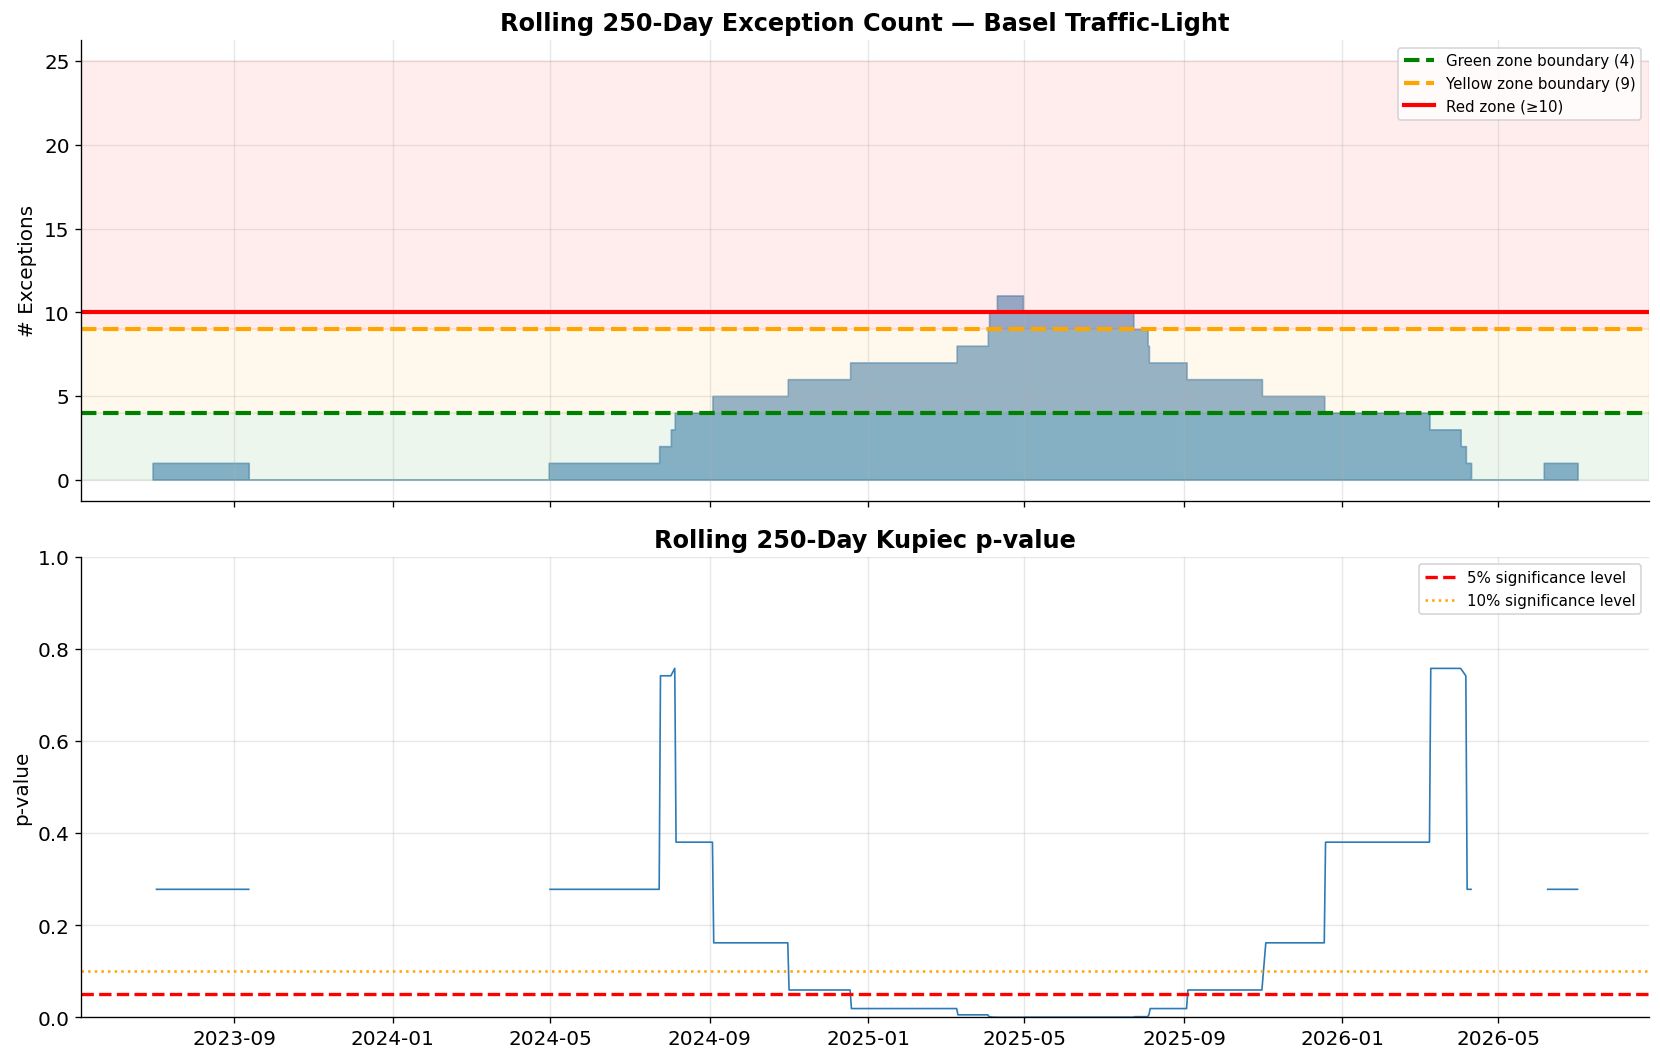

Basel Traffic-Light Summary
  Last 250-day exception count : 1
  Current zone                 : 🟢 Green
  Capital multiplier           : 3.0

Zone thresholds (Basel BCBS):
  Green  : 0–4   exceptions  → multiplier  3.00
  Yellow : 5–9   exceptions  → multiplier  3.40–3.85
  Red    : ≥ 10  exceptions  → multiplier  4.00 (model disqualification)


In [14]:
# ── Basel traffic-light: rolling 250-day exception count ─────────────────────
roll_250 = violations.rolling(250).sum()

def basel_zone(count):
    if count <= 4:   return 'Green'
    elif count <= 9: return 'Yellow'
    else:            return 'Red'

# Most recent 250-day count
last_250_count = int(roll_250.dropna().iloc[-1])
current_zone   = basel_zone(last_250_count)

# ── Rolling Kupiec p-values (250-day) ─────────────────────────────────────────
pval_roll = []
for i in range(250, len(violations)):
    n_v = violations.iloc[i - 250: i].sum()
    _, pv = kupiec_pof(int(n_v), 250, BT_ALPHA)
    pval_roll.append(pv if pv is not None else np.nan)

pval_series = pd.Series(pval_roll, index=violations.index[250:])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].fill_between(roll_250.index, roll_250, step='post', color='steelblue', alpha=0.6)
axes[0].axhline(4,  color='green',  lw=2.5, ls='--', label='Green zone boundary (4)')
axes[0].axhline(9,  color='orange', lw=2.5, ls='--', label='Yellow zone boundary (9)')
axes[0].axhline(10, color='red',    lw=2.5, ls='-',  label='Red zone (≥10)')
axes[0].axhspan(0,  4,  alpha=0.07, color='green')
axes[0].axhspan(4,  9,  alpha=0.07, color='orange')
axes[0].axhspan(9,  25, alpha=0.07, color='red')
axes[0].set_title('Rolling 250-Day Exception Count — Basel Traffic-Light', fontweight='bold')
axes[0].set_ylabel('# Exceptions')
axes[0].legend(fontsize=9)

axes[1].plot(pval_series.index, pval_series, color='#2C7BB6', lw=1)
axes[1].axhline(0.05, color='red', lw=2, ls='--', label='5% significance level')
axes[1].axhline(0.10, color='orange', lw=1.5, ls=':', label='10% significance level')
axes[1].set_title('Rolling 250-Day Kupiec p-value', fontweight='bold')
axes[1].set_ylabel('p-value')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
zone_color_map = {'Green': '🟢', 'Yellow': '🟡', 'Red': '🔴'}
multiplier_map = {'Green': 3.0, 'Yellow': 3.5, 'Red': 4.0}
print('Basel Traffic-Light Summary')
print(f'  Last 250-day exception count : {last_250_count}')
print(f'  Current zone                 : {zone_color_map.get(current_zone, current_zone)} {current_zone}')
print(f'  Capital multiplier           : {multiplier_map[current_zone]}')
print()
print('Zone thresholds (Basel BCBS):')
print('  Green  : 0–4   exceptions  → multiplier  3.00')
print('  Yellow : 5–9   exceptions  → multiplier  3.40–3.85')
print('  Red    : ≥ 10  exceptions  → multiplier  4.00 (model disqualification)')

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 7 — ES Backtesting: Acerbi-Szekely Test</span><br><span style="color:#BDC3C7;font-size:0.93em">Slide 14 · T1 statistic · Violation-day loss vs ES forecast · Calibration plot</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Slide 14</b> · Acerbi-Szekely (2014) ES Backtest</div>

Acerbi & Szekely (2014) propose a test statistic that directly probes ES calibration:
$$T_1 = \frac{1}{T(1-\alpha)} \sum_{t=1}^{T} \frac{R_t}{\widehat{\text{ES}}_t} I_t + 1$$

where $I_t = \mathbf{1}\{R_t < -\widehat{\text{VaR}}_t\}$ is the exception indicator.

- Under $H_0$ (correct ES): $\mathbb{E}[T_1] = 0$
- $T_1 < 0$ → ES systematically understates tail losses (model is too optimistic)
- $T_1 > 0$ → ES overstates tail losses (model is too conservative)

<div style="border-left:5px solid #27AE60;background:#0A2A1A;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#58D68D">&#128161;</b> The Financial Risk Manager Handbook (GARP, 7th ed.) discusses ES backtesting challenges: unlike VaR, ES cannot be directly elicited (Gneiting, 2011), so the Acerbi-Szekely test uses an indirect approach comparing realised losses on violation days to the ES forecast. A full significance test requires a bootstrap or parametric simulation.</div>

In [15]:
# ── Acerbi-Szekely T1 statistic ───────────────────────────────────────────────
# Note: es_roll is the ES forecast, test_rets are realised returns, violations is I_t
# R_t is negative on bad days; ES is stored as positive (loss), so we negate es_roll

# T1 = (1 / (T * (1-alpha))) * sum(R_t / ES_t * I_t) + 1
# where ES_t is the forecast expressed as a POSITIVE loss
T1_num = (test_rets.values / es_roll.values * violations.values).sum()
T1     = T1_num / (T_bt * (1 - BT_ALPHA)) + 1

print('Acerbi-Szekely ES Backtest (T1 statistic)')
print(f'  T1 statistic : {T1:.6f}')
print(f'  Interpretation: ', end='')
if T1 < -0.15:
    print('ES significantly understates tail risk ✗')
elif T1 < 0:
    print('ES mildly underestimates (within noise range) ~')
else:
    print('ES appears well-calibrated or conservative ✓')

# ── Bootstrap p-value for T1 ──────────────────────────────────────────────────
# Under H0: resample returns using es_roll as the true ES, then compute T1
np.random.seed(99)
n_boot = 1000
boot_T1 = []
for _ in range(n_boot):
    idx_boot = np.random.choice(len(test_rets), size=len(test_rets), replace=True)
    r_b  = test_rets.values[idx_boot]
    es_b = es_roll.values[idx_boot]
    var_b = var_roll.values[idx_boot]
    viol_b = (r_b < -var_b).astype(float)
    T1_b_num = (r_b / es_b * viol_b).sum()
    boot_T1.append(T1_b_num / (len(r_b) * (1 - BT_ALPHA)) + 1)

boot_T1 = np.array(boot_T1)
boot_pval = (boot_T1 <= T1).mean()  # one-sided: p(T1_boot <= observed)

print(f'  Bootstrap p-value ({n_boot} resamples): {boot_pval:.4f}')

Acerbi-Szekely ES Backtest (T1 statistic)
  T1 statistic : -0.546087
  Interpretation: ES significantly understates tail risk ✗
  Bootstrap p-value (1000 resamples): 0.4730


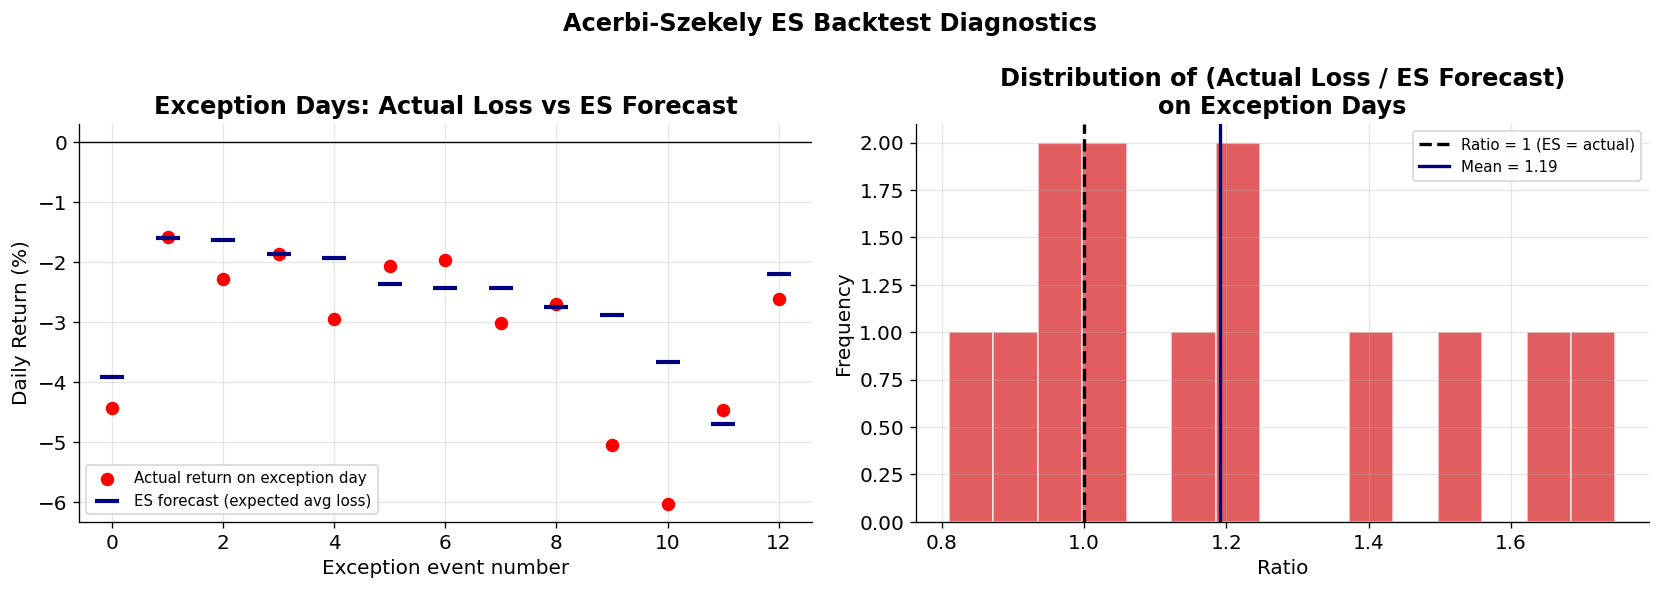

In [16]:
# ── Plot: violation-day losses vs ES forecast ─────────────────────────────────
if len(viol_idx) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    actual_losses = test_rets.loc[viol_idx] * 100
    es_forecasts  = -es_roll.loc[viol_idx] * 100   # sign: negative = loss direction

    axes[0].scatter(range(len(viol_idx)), actual_losses, color='red', s=50, zorder=5,
                    label='Actual return on exception day')
    axes[0].scatter(range(len(viol_idx)), es_forecasts, color='navy',
                    marker='_', s=200, lw=2.5, zorder=5, label='ES forecast (expected avg loss)')
    axes[0].axhline(0, color='black', lw=0.8)
    axes[0].set_title('Exception Days: Actual Loss vs ES Forecast', fontweight='bold')
    axes[0].set_xlabel('Exception event number')
    axes[0].set_ylabel('Daily Return (%)')
    axes[0].legend(fontsize=9)

    # Ratio distribution
    ratios_vd = actual_losses.values / es_forecasts.values
    axes[1].hist(ratios_vd[np.isfinite(ratios_vd)], bins=15,
                 color='#D7191C', alpha=0.7, edgecolor='white')
    axes[1].axvline(1.0, color='black', lw=2, ls='--', label='Ratio = 1 (ES = actual)')
    axes[1].axvline(np.nanmean(ratios_vd), color='navy', lw=2,
                    label=f'Mean = {np.nanmean(ratios_vd):.2f}')
    axes[1].set_title('Distribution of (Actual Loss / ES Forecast)\non Exception Days', fontweight='bold')
    axes[1].set_xlabel('Ratio')
    axes[1].set_ylabel('Frequency')
    axes[1].legend(fontsize=9)

    plt.suptitle('Acerbi-Szekely ES Backtest Diagnostics', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No exceptions in the backtest period — cannot produce Acerbi-Szekely plot.')

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Session Summary &amp; Key Takeaways</span><br><span style="color:#BDC3C7;font-size:0.93em">Slide 15 · What we learned · Connections to Session 3 VaR and Session 5 Credit Risk</span></div>

In [17]:
# ── Session 4 results summary ─────────────────────────────────────────────────
summary_data = {
    'Metric': [
        '99% VaR — Parametric (Normal)',
        '99% VaR — Historical Sim.',
        '99% VaR — Monte Carlo',
        '99% ES  — Parametric (Normal)',
        '99% ES  — Historical Sim.',
        f'99% ES  — Parametric (t, ν={nu_t:.1f})',
        'ES/VaR ratio (Normal)',
        f'ES/VaR ratio (t, ν={nu_t:.1f})',
        'Kupiec LR stat',
        'Kupiec p-value',
        'Christoffersen LR stat',
        'Christoffersen p-value',
        'Basel zone (latest 250d)',
        'Acerbi-Szekely T1',
    ],
    'Value': [
        f'{v_n*100:.3f}%',
        f'{v_h*100:.3f}%',
        f'{v_mc*100:.3f}%',
        f'{e_n*100:.3f}%',
        f'{e_h*100:.3f}%',
        f'{e_t*100:.3f}%',
        f'{e_n/v_n:.4f}',
        f'{e_t/v_t:.4f}',
        f'{lr_uc:.4f}',
        f'{pval_uc:.4f}',
        f'{lr_ind:.4f}',
        f'{pval_ind:.4f}',
        f'{current_zone} ({last_250_count} exceptions)',
        f'{T1:.6f}',
    ]
}
summary_df = pd.DataFrame(summary_data)
display(summary_df.to_string(index=False))

'                         Metric                Value\n  99% VaR — Parametric (Normal)               2.463%\n      99% VaR — Historical Sim.               2.973%\n          99% VaR — Monte Carlo               2.471%\n  99% ES  — Parametric (Normal)               2.829%\n      99% ES  — Historical Sim.               3.959%\n99% ES  — Parametric (t, ν=3.9)               4.012%\n          ES/VaR ratio (Normal)               1.1486\n        ES/VaR ratio (t, ν=3.9)               1.4099\n                 Kupiec LR stat               0.8185\n                 Kupiec p-value               0.3656\n         Christoffersen LR stat               6.7786\n         Christoffersen p-value               0.0092\n       Basel zone (latest 250d) Green (1 exceptions)\n              Acerbi-Szekely T1            -0.546087'

### Key takeaways

1. **ES is the right risk measure for tails** — it penalises large tail losses, unlike VaR which is indifferent to the size of the shortfall.
2. **Sub-additivity matters** — VaR can report lower combined risk than the sum of individual risks, creating a regulatory arbitrage incentive. ES cannot.
3. **Distribution choice dominates** — the ES/VaR ratio under a t(ν=4) distribution is dramatically higher than under normality. Model selection is a first-order decision.
4. **GARCH delivers time-varying risk** — static models underestimate risk during crises and overestimate it in calm periods. Dynamic models are indispensable.
5. **Backtesting is mandatory, not optional** — the Kupiec and Christoffersen tests provide rigorous statistical evidence; exception *clustering* is often a bigger problem than the total count.
6. **Basel zones translate model risk into capital** — a yellow-zone model costs real money in additional capital charges.

**Next session (Session 5)**: Credit Risk I — structural models, Merton framework, default probability from equity prices.

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Exercise — Build Your Own VaR Backtest &amp; Report the Basel Zone</span><br><span style="color:#BDC3C7;font-size:0.93em">Parts A–E · Choose your own asset · Backtest · Report zone · Reflect</span></div>

## Part A — Choose an Asset and Download Data (required)

1. Pick **any** single equity or ETF of your choice (not SPY).
2. Download daily prices for the period `2021-07-01` to `2026-07-01` using yfinance.
3. Compute log returns and report: number of observations, mean, std, skewness, excess kurtosis.
4. Are the returns normal? Run a Jarque-Bera test and state your conclusion.

## Part B — ES Three Ways (required)

1. Compute the full-sample 99% VaR and ES using: (a) Parametric Normal, (b) Historical Sim., (c) Monte Carlo.
2. Report the ES/VaR ratio for each method. Which is largest and why?
3. Fit a Student-t distribution and recompute parametric ES. How does the ES/VaR ratio change?

## Part C — Rolling Backtest (required)

1. Implement a **rolling 252-day historical simulation** 99% VaR backtest.
2. Plot: returns, VaR line, exceptions (scatter).
3. Report total exception count, expected count, and exception rate.

## Part D — Statistical Tests and Basel Zone (required)

1. Run the **Kupiec POF** test. Report LR statistic, p-value, decision at 5% significance.
2. Run the **Christoffersen independence** test. Are exceptions clustered?
3. Determine the **Basel traffic-light zone** for the most recent 250-trading-day window.
4. Compute the **Acerbi-Szekely T1 statistic**. Is ES well-calibrated?

## Part E — Reflection (required, most heavily graded)

Answer the following in 150–250 words:
- What does your Basel zone tell you about the model's reliability?
- If you were a risk manager using this model for regulatory capital, what would you do differently?
- Why might historical simulation produce more exceptions than parametric VaR on your asset?
- How would switching from a 99% VaR to a 97.5% ES (the Basel IV standard) change your exception count and zone?

In [18]:
# Part A — Download your own asset and compute return statistics
# YOUR CODE HERE


In [19]:
# Part B — Compute 99% VaR and ES using three methods
# YOUR CODE HERE


In [20]:
# Part C — Rolling 252-day historical simulation backtest + exception plot
# YOUR CODE HERE


In [21]:
# Part D — Kupiec test, Christoffersen test, Basel zone, Acerbi-Szekely T1
# YOUR CODE HERE


## Part E — Reflection

*Write your 150–250 word reflection here.*